# S10 · Transformaciones de variables

NovaMarket · Preprocesamiento de Datos · Ricardo Borja

---

Creación de variables temporales a partir de la fecha del pedido, variables derivadas del texto del
comentario, discretización de la edad en grupos de negocio y transformación de `monto_compra` con
logaritmo y con Box-Cox, ajustando este último únicamente con el conjunto de entrenamiento.

Insumo: `S09_PD_Borja_DatasetCodificado.csv`, salida de la sesión de codificación. La columna
`comentario_cliente` se retiró en esa sesión al quedar codificada en one-hot, así que para las
variables de texto se recupera desde `S08_PD_Grupo05_DatasetEscalado.csv`, uniendo por `id_pedido`.
Salida: `S10_PD_Borja_DatasetTransformado.csv`.

Todas las columnas originales que se transforman (`fecha_pedido`, `comentario_cliente`,
`edad_cliente`, `monto_compra`) se conservan junto a las nuevas. La partición entrenamiento / prueba
sigue siendo la de la columna `conjunto`, heredada de la sesión 8.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.facecolor": "white", "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 80)

ENTRADA = "S09_PD_Borja_DatasetCodificado.csv"
ENTRADA_TEXTO = "S08_PD_Grupo05_DatasetEscalado.csv"
SALIDA = "S10_PD_Borja_DatasetTransformado.csv"

df = pd.read_csv(ENTRADA, low_memory=False)
texto = pd.read_csv(ENTRADA_TEXTO, usecols=["id_pedido", "comentario_cliente"], low_memory=False)

pd.DataFrame({"valor": [len(df), df.shape[1], len(texto),
                        bool((df["id_pedido"].to_numpy() == texto["id_pedido"].to_numpy()).all())]},
             index=["filas", "columnas", "filas con comentario recuperado", "mismo orden de id_pedido"])

,valor
filas,620000
columnas,104
filas con comentario recuperado,620000
mismo orden de id_pedido,True


In [2]:
df = df.merge(texto, on="id_pedido", how="left", validate="one_to_one")

es_train = df["conjunto"] == "entrenamiento"
es_test = df["conjunto"] == "prueba"

pd.DataFrame({"valor": [int(df["comentario_cliente"].isna().sum()), int(es_train.sum()), int(es_test.sum())]},
             index=["comentarios sin recuperar (debe ser 0)", "filas de entrenamiento", "filas de prueba"])

,valor
comentarios sin recuperar (debe ser 0),0
filas de entrenamiento,496000
filas de prueba,124000


---
# Parte 1 · Variables temporales

## 1.1 · Confirmar que la fecha es una fecha

Al leer un CSV, pandas trae `fecha_pedido` como texto. Antes de extraer cualquier componente hay que
convertirla a `datetime64[ns]` y confirmar el tipo, porque el accesor `.dt` no existe sobre texto.
Los valores que no puedan interpretarse quedan como `NaT`, que es el nulo de las fechas.

In [3]:
tipo_antes = str(df["fecha_pedido"].dtype)
df["fecha_pedido"] = pd.to_datetime(df["fecha_pedido"], errors="coerce")
tipo_despues = str(df["fecha_pedido"].dtype)

pd.DataFrame({"valor": [
    tipo_antes, tipo_despues, tipo_despues == "datetime64[ns]",
    int(df["fecha_pedido"].isna().sum()),
    int(df["fecha_pedido_sin_dato"].sum()), int(df["fecha_pedido_invalida"].sum()),
    int(df["fecha_pedido_sin_dato"].sum() + df["fecha_pedido_invalida"].sum()),
    df["fecha_pedido"].min().date(), df["fecha_pedido"].max().date(),
]}, index=["tipo antes de convertir", "tipo después de convertir", "es datetime64[ns]",
           "fechas nulas (NaT)", "bandera fecha_pedido_sin_dato", "bandera fecha_pedido_invalida",
           "suma de las dos banderas", "fecha mínima", "fecha máxima"])

,valor
tipo antes de convertir,object
tipo después de convertir,datetime64[ns]
es datetime64[ns],True
fechas nulas (NaT),22000
bandera fecha_pedido_sin_dato,5534
bandera fecha_pedido_invalida,16466
suma de las dos banderas,22000
fecha mínima,2025-01-01
fecha máxima,2027-12-28


La columna queda en `datetime64[ns]`. Las 22.000 fechas nulas no son un problema nuevo: son
exactamente las 5.534 sin dato más las 16.466 inválidas que la sesión de limpieza ya había marcado
con sus banderas. Para esas filas, las variables temporales quedarán nulas y las banderas siguen
diciendo por qué.

## 1.2 · Extraer las variables temporales con el accesor `.dt`

Cuatro variables: el mes (1 a 12), el trimestre (1 a 4), el día de la semana (0 es lunes y 6 es
domingo, la convención de pandas) y una bandera de fin de semana (sábado o domingo). Se guardan con
el tipo entero anulable `Int64` para que las filas sin fecha conserven el nulo en lugar de convertir
toda la columna a decimal.

In [4]:
df["mes_pedido"] = df["fecha_pedido"].dt.month.astype("Int64")
df["trimestre_pedido"] = df["fecha_pedido"].dt.quarter.astype("Int64")
df["dia_semana_pedido"] = df["fecha_pedido"].dt.dayofweek.astype("Int64")
df["es_fin_semana_pedido"] = (df["fecha_pedido"].dt.dayofweek >= 5).astype("Int64")
df.loc[df["fecha_pedido"].isna(), "es_fin_semana_pedido"] = pd.NA

TEMPORALES = ["mes_pedido", "trimestre_pedido", "dia_semana_pedido", "es_fin_semana_pedido"]

df[["fecha_pedido"] + TEMPORALES].head(8)

,fecha_pedido,mes_pedido,trimestre_pedido,dia_semana_pedido,es_fin_semana_pedido
0,2025-11-15,11,4,5,1
1,2026-03-05,3,1,3,0
2,2025-03-13,3,1,3,0
3,2025-06-27,6,2,4,0
4,2025-05-01,5,2,3,0
5,2025-08-29,8,3,4,0
6,2026-03-10,3,1,1,0
7,2027-08-19,8,3,3,0


In [5]:
pd.DataFrame({
    "tipo": [str(df[c].dtype) for c in TEMPORALES],
    "mínimo": [df[c].min() for c in TEMPORALES],
    "máximo": [df[c].max() for c in TEMPORALES],
    "nulos": [int(df[c].isna().sum()) for c in TEMPORALES],
    "nulos coinciden con fechas nulas": [bool((df[c].isna() == df["fecha_pedido"].isna()).all()) for c in TEMPORALES],
}, index=TEMPORALES)

,tipo,mínimo,máximo,nulos,nulos coinciden con fechas nulas
mes_pedido,Int64,1,12,22000,True
trimestre_pedido,Int64,1,4,22000,True
dia_semana_pedido,Int64,0,6,22000,True
es_fin_semana_pedido,Int64,0,1,22000,True


In [6]:
# verificación cruzada: el día de la semana extraído debe coincidir con el nombre del día de la fecha
muestra = df.loc[df["fecha_pedido"].notna(), ["fecha_pedido", "dia_semana_pedido", "es_fin_semana_pedido"]].head(7).copy()
muestra["nombre del día"] = muestra["fecha_pedido"].dt.day_name()
display(muestra)

dist_dia = df["dia_semana_pedido"].value_counts(normalize=True).sort_index().rename("proporción").to_frame()
dist_dia["nombre"] = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
dist_dia["fin de semana"] = dist_dia.index >= 5
display(dist_dia.round(4))

pd.DataFrame({"valor": [
    round(float(df["es_fin_semana_pedido"].mean()), 4), round(2 / 7, 4),
    df["mes_pedido"].value_counts().sort_index().to_dict(),
    df["trimestre_pedido"].value_counts().sort_index().to_dict(),
]}, index=["proporción de fin de semana", "proporción esperada si los días son uniformes (2/7)",
           "pedidos por mes", "pedidos por trimestre"])

,fecha_pedido,dia_semana_pedido,es_fin_semana_pedido,nombre del día
0,2025-11-15,5,1,Saturday
1,2026-03-05,3,0,Thursday
2,2025-03-13,3,0,Thursday
3,2025-06-27,4,0,Friday
4,2025-05-01,3,0,Thursday
5,2025-08-29,4,0,Friday
6,2026-03-10,1,0,Tuesday


,proporción,nombre,fin de semana
dia_semana_pedido,,,
0,0.1421,lunes,False
1,0.142,martes,False
2,0.1442,miércoles,False
3,0.1433,jueves,False
4,0.1445,viernes,False
5,0.1422,sábado,True
6,0.1416,domingo,True


,valor
proporción de fin de semana,0.2839
proporción esperada si los días son uniformes (2/7),0.2857
pedidos por mes,"{1: 73423, 2: 66651, 3: 73458, 4: 70739, 5: 54870, 6: 36038, 7: 37447, 8: 37..."
pedidos por trimestre,"{1: 213532, 2: 161647, 3: 111278, 4: 111543}"


Las cuatro variables se extraen correctamente: la muestra confirma que el código 5 corresponde a
sábado y el 6 a domingo (`day_name` lo verifica de forma independiente), la bandera de fin de semana
vale 1 solo en esos dos días, y la proporción de pedidos en fin de semana (28,4 %) coincide con los
2/7 (28,6 %) que se esperan cuando los pedidos se reparten de forma uniforme entre los días. Los nulos de las
cuatro columnas coinciden fila a fila con las fechas nulas.

Un detalle que queda registrado como pendiente y que no es de esta sesión: el rango de fechas llega
hasta finales de 2027, así que hay pedidos con fecha futura que pasaron los filtros de la sesión de
limpieza. Las variables temporales se extraen igual, pero un análisis de estacionalidad debería
revisar ese tramo.

---
# Parte 2 · Variables de texto

## 2.1 · Rellenar los vacíos antes de calcular

Cualquier función de texto (`len`, `split`, expresiones regulares) falla o devuelve nulo sobre un
`NaN`. Por eso el primer paso es `fillna("")`. En este dataset hay un segundo caso: la sesión de
imputación dejó 88.000 comentarios ausentes con el texto `sin comentario` y los marcó en la bandera
`sin_comentario`. Ese texto no es un comentario del cliente, así que se trata como vacío para las
variables de texto; de lo contrario `longitud_comentario` valdría 14 en pedidos que en realidad no
tienen comentario.

In [7]:
comentario = df["comentario_cliente"].fillna("").astype(str).str.strip()
placeholder = comentario.str.lower() == "sin comentario"
comentario = comentario.mask(placeholder, "")

pd.DataFrame({"valor": [
    int(df["comentario_cliente"].isna().sum()), int(placeholder.sum()), int(df["sin_comentario"].sum()),
    bool((placeholder == df["sin_comentario"]).all()), int((comentario == "").sum()),
]}, index=["nulos en comentario_cliente", "registros con el texto 'sin comentario'",
           "bandera sin_comentario", "el texto y la bandera coinciden fila a fila",
           "comentarios tratados como vacíos"])

,valor
nulos en comentario_cliente,0
registros con el texto 'sin comentario',88000
bandera sin_comentario,88000
el texto y la bandera coinciden fila a fila,True
comentarios tratados como vacíos,88000


## 2.2 · Cuatro variables derivadas del texto

`longitud_comentario` es el número de caracteres, `num_palabras_comentario` el número de palabras
separadas por espacios, `tiene_comentario` vale 1 si el texto no está vacío, y `menciona_demora` vale
1 si el comentario habla de demoras, tardanzas o retrasos, que es la queja que más interesa a
logística. Como los comentarios vienen de un catálogo de trece frases, la tabla de abajo muestra el
valor de las cuatro variables para cada frase y permite verificar el cálculo a simple vista.

In [8]:
PATRON_DEMORA = r"demor|tard[oó]|retras|se demor"

df["longitud_comentario"] = comentario.str.len().astype(int)
df["num_palabras_comentario"] = comentario.str.split().str.len().fillna(0).astype(int)
df["tiene_comentario"] = (comentario != "").astype(int)
df["menciona_demora"] = comentario.str.lower().str.contains(PATRON_DEMORA, regex=True).astype(int)

TEXTO = ["longitud_comentario", "num_palabras_comentario", "tiene_comentario", "menciona_demora"]

catalogo = (pd.DataFrame({"comentario": df["comentario_cliente"]}).join(df[TEXTO])
            .groupby("comentario")[TEXTO].first()
            .join(df["comentario_cliente"].value_counts().rename("pedidos"))
            .sort_values("pedidos", ascending=False))
catalogo

,longitud_comentario,num_palabras_comentario,tiene_comentario,menciona_demora,pedidos
comentario,,,,,
sin comentario,0,0,0,0,88000
No era lo que esperaba,22,5,1,0,44662
Llegó incompleto el pedido,26,4,1,0,44557
Cumplió con lo prometido,24,4,1,0,44426
Muy buen precio,15,3,1,0,44422
Me costó encontrar el producto en la app,40,8,1,0,44409
"Excelente calidad, volvería a comprar",37,5,1,0,44393
Pésima experiencia con el empaque,33,5,1,0,44378
"Todo perfecto, llegó a tiempo",29,5,1,0,44347


In [9]:
pd.DataFrame({"valor": [
    bool((df["tiene_comentario"] == (~df["sin_comentario"]).astype(int)).all()),
    int((df.loc[df["tiene_comentario"] == 0, ["longitud_comentario", "num_palabras_comentario"]].sum(axis=1) != 0).sum()),
    int(df["menciona_demora"].sum()),
    round(100 * df["menciona_demora"].mean(), 2),
    df.loc[df["menciona_demora"] == 1, "comentario_cliente"].unique().tolist(),
]}, index=["tiene_comentario es el inverso de la bandera sin_comentario",
           "vacíos con longitud o palabras distintas de cero (debe ser 0)",
           "pedidos que mencionan demora", "% de pedidos que mencionan demora",
           "frases que activan menciona_demora"])

,valor
tiene_comentario es el inverso de la bandera sin_comentario,True
vacíos con longitud o palabras distintas de cero (debe ser 0),0
pedidos que mencionan demora,44140
% de pedidos que mencionan demora,7.12
frases que activan menciona_demora,[Buena atención pero demoró mucho]


Las cuatro variables son consistentes con el catálogo: los 88.000 registros sin comentario quedan
con longitud 0, cero palabras y `tiene_comentario = 0`, y `tiene_comentario` es exactamente el
inverso de la bandera que ya existía. `menciona_demora` se activa únicamente con la frase
"Buena atención pero demoró mucho", que es la única del catálogo que habla de tiempos de entrega;
"Todo perfecto, llegó a tiempo" no la activa porque no es una queja de demora. Con texto libre real
el patrón tendría que ampliarse, pero con este catálogo cubre el caso que existe.

---
# Parte 3 · Discretización de la edad

## 3.1 · Bins fijos de negocio, no calculados de los datos

Los límites de los grupos se definen por criterio comercial y no por cuantiles: así los grupos
significan lo mismo en cualquier corte del dataset y en cualquier reporte futuro, y no cambian si
cambia la distribución de edades. Los rangos son cerrados por la derecha: 18 a 25, 26 a 35, 36 a 50,
51 a 65, y 66 o más. El límite inferior del primer bin (17) queda por debajo de la edad mínima
posible (18) y el superior del último (120) por encima de cualquier edad real, para que ningún
cliente quede fuera por un límite mal puesto. Las edades nulas heredadas de sesiones anteriores
reciben la etiqueta explícita "Sin dato".

In [10]:
BINS_EDAD = [17, 25, 35, 50, 65, 120]
ETIQUETAS_EDAD = ["18 a 25 (joven)", "26 a 35 (adulto joven)", "36 a 50 (adulto)",
                  "51 a 65 (adulto maduro)", "66 o más (adulto mayor)"]

df["grupo_edad"] = pd.cut(df["edad_cliente"], bins=BINS_EDAD, labels=ETIQUETAS_EDAD, right=True)
df["grupo_edad"] = df["grupo_edad"].cat.add_categories(["Sin dato"]).fillna("Sin dato")

resumen_edad = df.groupby("grupo_edad", observed=False)["edad_cliente"].agg(["size", "min", "max"])
resumen_edad.columns = ["clientes", "edad mínima", "edad máxima"]
resumen_edad

,clientes,edad mínima,edad máxima
grupo_edad,,,
18 a 25 (joven),80354,18.0,25.0
26 a 35 (adulto joven),100772,26.0,35.0
36 a 50 (adulto),151046,36.0,50.0
51 a 65 (adulto maduro),150946,51.0,65.0
66 o más (adulto mayor),100882,66.0,75.0
Sin dato,36000,NaN,NaN


In [11]:
con_edad = df["edad_cliente"].notna()
pd.DataFrame({"valor": [
    int(con_edad.sum()), int(df["edad_cliente"].isna().sum()),
    int((df.loc[con_edad, "grupo_edad"] == "Sin dato").sum()),
    int(df["grupo_edad"].isna().sum()),
    float(df["edad_cliente"].min()), float(df["edad_cliente"].max()),
    bool(resumen_edad["clientes"].sum() == len(df)),
]}, index=["clientes con edad", "clientes sin edad", "clientes con edad que quedaron sin grupo (debe ser 0)",
           "grupos nulos (debe ser 0)", "edad mínima del dataset", "edad máxima del dataset",
           "la suma de los grupos reconstruye el total"])

,valor
clientes con edad,584000
clientes sin edad,36000
clientes con edad que quedaron sin grupo (debe ser 0),0
grupos nulos (debe ser 0),0
edad mínima del dataset,18.0
edad máxima del dataset,75.0
la suma de los grupos reconstruye el total,True


Ningún cliente con edad quedó sin grupo y ningún grupo quedó nulo: la tabla de mínimos y máximos por
grupo muestra que cada bin recibe exactamente el rango que dice su etiqueta (18 a 25, 26 a 35, y así
sucesivamente), sin solapes ni huecos, y las 36.000 edades nulas quedan en "Sin dato", con el nulo
original intacto en `edad_cliente` para trazabilidad.

---
# Parte 4 · Transformaciones de `monto_compra`

## 4.1 · El sesgo antes de transformar

Antes de aplicar cualquier transformación se mide la asimetría con `.skew()`. Un sesgo positivo
grande significa cola derecha larga: muchas compras pequeñas y pocas muy grandes. También se
registran dos particularidades de esta columna que condicionan las transformaciones: los 79.291
nulos heredados y los 8.401 montos exactamente en cero, que corresponden a pedidos de cero unidades
(hallazgo documentado en la sesión 8).

In [12]:
m = df["monto_compra"]
pd.DataFrame({"valor": [
    round(float(m.skew()), 4), int(m.isna().sum()), int((m == 0).sum()), int((m < 0).sum()),
    float(m[m > 0].min()), float(m.max()), round(float(m.median()), 1),
]}, index=["sesgo de monto_compra", "nulos", "montos en cero", "montos negativos",
           "mínimo positivo", "máximo", "mediana"])

,valor
sesgo de monto_compra,1.997800e+00
nulos,7.929100e+04
montos en cero,8.401000e+03
montos negativos,0.000000e+00
mínimo positivo,1.580000e+04
máximo,4.457500e+06
mediana,4.686000e+05


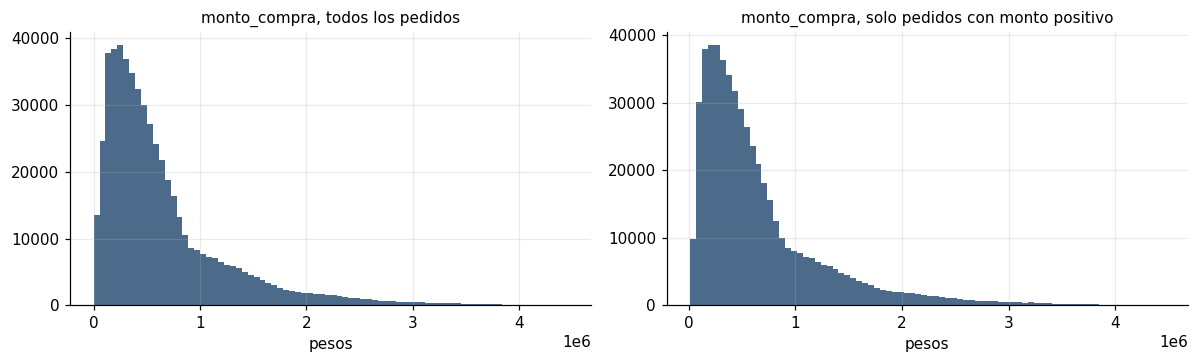

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(m.dropna(), bins=80, color="#4C6B8A")
ax[0].set_title("monto_compra, todos los pedidos", fontsize=10)
ax[1].hist(m[m > 0], bins=80, color="#4C6B8A")
ax[1].set_title("monto_compra, solo pedidos con monto positivo", fontsize=10)
for a in ax:
    a.set_xlabel("pesos")
fig.tight_layout()
plt.show()

## 4.2 · Logaritmo sobre el dataset completo

`np.log1p(x)` calcula $\log(1 + x)$. Es una función fija: no tiene parámetros que aprender de los
datos, así que aplicarla a una fila no usa información de ninguna otra fila. Por eso se puede aplicar
sobre el dataset completo sin dividir antes en entrenamiento y prueba y sin riesgo de fuga. Se usa
`log1p` en lugar de `log` para que los montos en cero den 0 en lugar de menos infinito.

In [14]:
df["monto_compra_log"] = np.log1p(df["monto_compra"])

pd.DataFrame({"valor": [
    round(float(df["monto_compra_log"].skew()), 4),
    round(float(df.loc[m > 0, "monto_compra_log"].skew()), 4),
    int(df["monto_compra_log"].isna().sum()),
    float(df["monto_compra_log"].min()), round(float(df["monto_compra_log"].max()), 4),
]}, index=["sesgo de monto_compra_log (todos)", "sesgo de monto_compra_log (sin los ceros)",
           "nulos (igual que el original)", "mínimo", "máximo"])

,valor
sesgo de monto_compra_log (todos),-5.3167
sesgo de monto_compra_log (sin los ceros),-0.1721
nulos (igual que el original),79291.0000
mínimo,0.0000
máximo,15.3101


## 4.3 · Box-Cox ajustado solo con entrenamiento

Box-Cox es una familia de transformaciones $y^{(\lambda)} = (y^\lambda - 1) / \lambda$ para
$\lambda \neq 0$, y $\log y$ para $\lambda = 0$. A diferencia del logaritmo, tiene un parámetro,
$\lambda$, que `PowerTransformer` aprende de los datos buscando el valor que más se acerca a la
normalidad. Como es un parámetro aprendido, el ajuste (`fit`) se hace únicamente con el conjunto de
entrenamiento y la transformación (`transform`) se aplica con ese mismo $\lambda$ a entrenamiento y
prueba. Si se ajustara con el dataset completo, $\lambda$ contendría información de la prueba.

Box-Cox exige valores estrictamente positivos, y `monto_compra` tiene ceros. Para poder incluirlos y
que la comparación con el logaritmo sea justa se transforma $1 + \text{monto}$, exactamente el mismo
desplazamiento que usa `log1p`. Los nulos no entran al ajuste y quedan nulos en la salida.

In [15]:
desplazado = (df["monto_compra"] + 1.0).to_frame("monto_mas_uno")
valido = desplazado["monto_mas_uno"].notna()

boxcox = PowerTransformer(method="box-cox", standardize=False)
boxcox.fit(desplazado.loc[es_train & valido])                                   # ajuste: solo entrenamiento

df["monto_compra_boxcox"] = np.nan
df.loc[valido, "monto_compra_boxcox"] = boxcox.transform(desplazado.loc[valido]).ravel()   # transformación: ambos conjuntos

# solo para mostrar la fuga que se evitó: el lambda que saldría ajustando con todo el dataset
boxcox_con_fuga = PowerTransformer(method="box-cox", standardize=False).fit(desplazado.loc[valido])

pd.DataFrame({"valor": [
    round(float(boxcox.lambdas_[0]), 6), round(float(boxcox_con_fuga.lambdas_[0]), 6),
    int((es_train & valido).sum()), int((es_test & valido).sum()),
    int(df["monto_compra_boxcox"].isna().sum()),
    round(float(df["monto_compra_boxcox"].skew()), 4),
    round(float(df.loc[m > 0, "monto_compra_boxcox"].skew()), 4),
]}, index=["lambda aprendido con entrenamiento", "lambda que saldría con el dataset completo (no se usa)",
           "filas usadas en el fit", "filas de prueba transformadas con ese lambda",
           "nulos en la salida (igual que el original)",
           "sesgo de monto_compra_boxcox (todos)", "sesgo de monto_compra_boxcox (sin los ceros)"])

,valor
lambda aprendido con entrenamiento,0.328597
lambda que saldría con el dataset completo (no se usa),0.328877
filas usadas en el fit,432457.000000
filas de prueba transformadas con ese lambda,108252.000000
nulos en la salida (igual que el original),79291.000000
sesgo de monto_compra_boxcox (todos),0.067800
sesgo de monto_compra_boxcox (sin los ceros),0.562900


In [16]:
# verificación: la transformación de prueba usa el lambda de entrenamiento, no uno propio
lam = float(boxcox.lambdas_[0])
manual = ((desplazado.loc[es_test & valido, "monto_mas_uno"] ** lam) - 1.0) / lam
pd.DataFrame({"valor": [
    bool(np.allclose(manual.to_numpy(), df.loc[es_test & valido, "monto_compra_boxcox"].to_numpy())),
    round(float(np.abs(manual.to_numpy() - df.loc[es_test & valido, "monto_compra_boxcox"].to_numpy()).max()), 10),
]}, index=["prueba reconstruida a mano con el lambda de entrenamiento", "diferencia máxima"])

,valor
prueba reconstruida a mano con el lambda de entrenamiento,True
diferencia máxima,0.0


## 4.4 · Comparación del sesgo

Se comparan las tres versiones de la variable, con todos los pedidos y excluyendo los montos en cero,
porque los ceros se comportan de forma distinta bajo cada transformación.

In [17]:
VERSIONES = ["monto_compra", "monto_compra_log", "monto_compra_boxcox"]
comparacion = pd.DataFrame({
    "sesgo (todos los pedidos)": [round(float(df[c].skew()), 4) for c in VERSIONES],
    "sesgo (sin montos en cero)": [round(float(df.loc[m > 0, c].skew()), 4) for c in VERSIONES],
    "sesgo en entrenamiento": [round(float(df.loc[es_train, c].skew()), 4) for c in VERSIONES],
    "sesgo en prueba": [round(float(df.loc[es_test, c].skew()), 4) for c in VERSIONES],
    "nulos": [int(df[c].isna().sum()) for c in VERSIONES],
}, index=VERSIONES)
comparacion

,sesgo (todos los pedidos),sesgo (sin montos en cero),sesgo en entrenamiento,sesgo en prueba,nulos
monto_compra,1.9978,2.0081,2.0038,1.9735,79291
monto_compra_log,-5.3167,-0.1721,-5.3178,-5.3122,79291
monto_compra_boxcox,0.0678,0.5629,0.0703,0.0575,79291


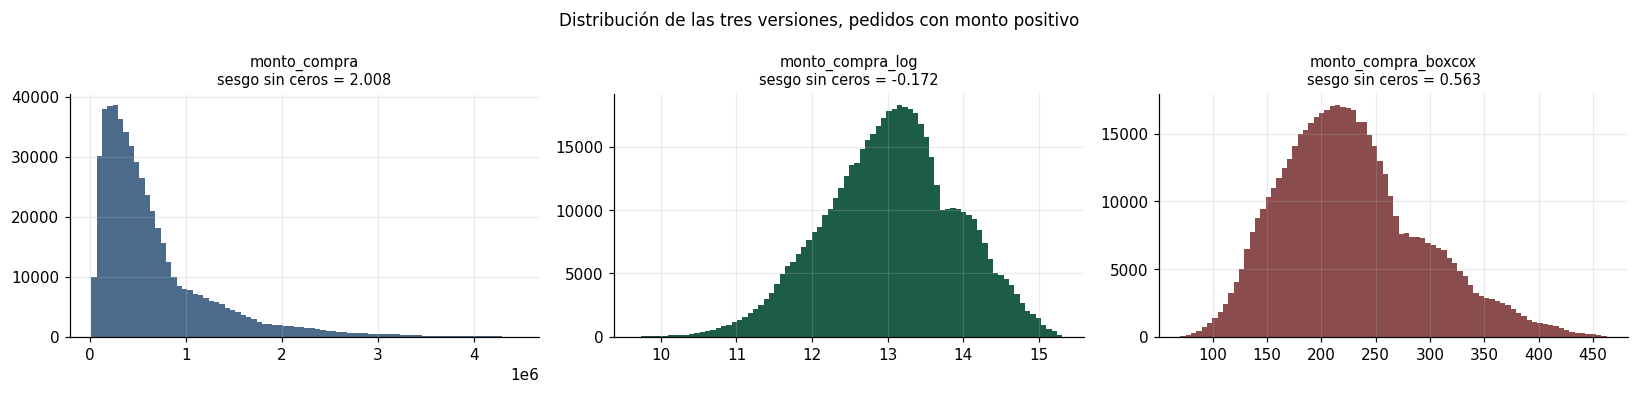

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, c, color in zip(ax, VERSIONES, ["#4C6B8A", "#1D5C48", "#8A4C4C"]):
    a.hist(df.loc[m > 0, c], bins=80, color=color)
    a.set_title(f"{c}\nsesgo sin ceros = {df.loc[m > 0, c].skew():.3f}", fontsize=9.5)
fig.suptitle("Distribución de las tres versiones, pedidos con monto positivo", fontsize=11)
fig.tight_layout()
plt.show()

### Lectura de la comparación de sesgo

**`monto_compra`** tiene sesgo 2,00: cola derecha larga, con la mediana (469 mil) muy por debajo del
máximo de 4,46 millones. Es la forma típica de una variable de montos, y el sesgo es prácticamente
igual en entrenamiento (2,00) y en prueba (1,97), lo que confirma que la partición no distorsiona la
distribución.

**`monto_compra_log`** tiene un sesgo de $-5{,}32$ si se calcula con todos los pedidos, pero de
$-0{,}17$ si se excluyen los montos en cero. La diferencia la explican los 8.401 ceros: `log1p(0)`
vale 0 mientras el resto de la columna queda entre 9,7 y 15,3, así que esos pedidos forman un bloque
aislado muy a la izquierda que el estadístico de sesgo lee como una cola izquierda enorme. Sobre las
compras reales el logaritmo hizo su trabajo: la distribución queda casi simétrica, apenas un poco
cargada a la izquierda.

**`monto_compra_boxcox`** muestra la trampa contraria. Con todos los pedidos su sesgo es 0,07, el
mejor de la tabla, pero sin los ceros es 0,56, peor que el del logaritmo. El $\lambda$ aprendido en
entrenamiento fue 0,33, no cero: `PowerTransformer` busca el $\lambda$ que hace más normal la
columna completa, y con 8.401 ceros creando una cola izquierda artificial, el óptimo es un
$\lambda$ intermedio que comprime menos la cola derecha para "compensar" esa cola izquierda. El
resultado es una variable que parece simétrica en conjunto pero que sigue sesgada a la derecha en
las compras reales. El parámetro aprendido se dejó arrastrar por un bloque de datos que no son
compras.

La diferencia entre el $\lambda$ de entrenamiento (0,328597) y el que saldría con el dataset
completo (0,328877) es pequeña, pero existe, y es exactamente la fuga que se evitó al ajustar solo
con entrenamiento; la verificación manual confirma que la prueba se transformó con el $\lambda$ de
entrenamiento y no con uno propio.

La conclusión práctica es doble. Para modelar el monto de las compras reales, el logaritmo deja la
variable en la escala más simétrica de las tres; Box-Cox solo lo haría si se ajustara excluyendo los
ceros. Y los pedidos con monto en cero deben tratarse como una categoría aparte (son los pedidos de
cero unidades, ya identificados en la sesión 8), porque ninguna transformación monótona los va a
integrar al resto de la distribución y, peor, pueden distorsionar el parámetro que Box-Cox aprende.

### Por qué el logaritmo sí se puede aplicar sobre el dataset completo y Box-Cox no

El logaritmo es una regla fija: $\log(1 + x)$ transforma cada valor usando únicamente ese valor. No
aprende nada de los datos, así que da lo mismo aplicarlo antes o después de dividir, y aplicarlo a
una fila de prueba no usa información de ninguna otra fila. Box-Cox, en cambio, tiene un parámetro
$\lambda$ que se estima maximizando la verosimilitud sobre las filas que se le entregan. Si se
ajusta con todo el dataset, ese $\lambda$ queda influido por las filas de prueba, y después la prueba
se transforma con un parámetro que ya la conocía. Es la misma lógica que los escaladores de la
sesión 8 y el target encoding de la sesión 9: todo lo que se aprende de los datos se aprende solo
con entrenamiento.

---
# Parte 5 · Consolidación y exportación

Se conservan todas las columnas de entrada, incluidas las originales que se transformaron, y se
agregan las once nuevas. `comentario_cliente` vuelve al dataset porque hace falta para reproducir
las variables de texto.

In [19]:
NUEVAS = TEMPORALES + TEXTO + ["grupo_edad", "monto_compra_log", "monto_compra_boxcox"]
ORIGINALES = ["fecha_pedido", "comentario_cliente", "edad_cliente", "monto_compra"]

# el objetivo y la partición al final, como en las sesiones anteriores
final = df[[c for c in df.columns if c not in ("fuga_cliente", "conjunto")] + ["fuga_cliente", "conjunto"]]

pd.DataFrame({"valor": [
    len(NUEVAS), ", ".join(NUEVAS),
    bool(all(c in final.columns for c in ORIGINALES)),
    final.shape[1],
]}, index=["columnas nuevas", "cuáles", "las cuatro columnas originales se conservan", "columnas finales"])

,valor
columnas nuevas,11
cuáles,"mes_pedido, trimestre_pedido, dia_semana_pedido, es_fin_semana_pedido, longi..."
las cuatro columnas originales se conservan,True
columnas finales,116


In [20]:
final.to_csv(SALIDA, index=False)
verificacion = pd.read_csv(SALIDA, low_memory=False)

pd.DataFrame({"valor": [
    SALIDA, f"{os.path.getsize(SALIDA) / 1048576:.1f} MB",
    len(df), len(final), len(verificacion),
    int((final["conjunto"] == "entrenamiento").sum()), int((final["conjunto"] == "prueba").sum()),
    len(final) - len(df),
    final.shape[1], verificacion.shape[1],
    bool(all(c in verificacion.columns for c in NUEVAS + ORIGINALES)),
]}, index=["archivo", "tamaño", "filas de entrada", "filas finales", "filas releídas del CSV",
           "filas de entrenamiento", "filas de prueba", "conciliación de filas (debe ser 0)",
           "columnas finales", "columnas releídas", "nuevas y originales presentes en el CSV releído"])

,valor
archivo,S10_PD_Borja_DatasetTransformado.csv
tamaño,322.8 MB
filas de entrada,620000
filas finales,620000
filas releídas del CSV,620000
filas de entrenamiento,496000
filas de prueba,124000
conciliación de filas (debe ser 0),0
columnas finales,116
columnas releídas,116


In [21]:
verificacion[["id_pedido", "fecha_pedido", "mes_pedido", "dia_semana_pedido", "es_fin_semana_pedido",
              "comentario_cliente", "longitud_comentario", "menciona_demora",
              "edad_cliente", "grupo_edad", "monto_compra", "monto_compra_log", "monto_compra_boxcox",
              "conjunto"]].head(6)

,id_pedido,fecha_pedido,mes_pedido,dia_semana_pedido,es_fin_semana_pedido,comentario_cliente,longitud_comentario,menciona_demora,edad_cliente,grupo_edad,monto_compra,monto_compra_log,monto_compra_boxcox,conjunto
0,P505195,2025-11-15,11.0,5.0,1.0,El domiciliario fue muy amable,30,0,32.0,26 a 35 (adulto joven),28700.0,10.264687,85.710610,prueba
1,P677836,2026-03-05,3.0,3.0,0.0,El producto llegó dañado,24,0,73.0,66 o más (adulto mayor),391400.0,12.877488,206.394109,entrenamiento
2,P387869,2025-03-13,3.0,3.0,0.0,El domiciliario fue muy amable,30,0,32.0,26 a 35 (adulto joven),NaN,NaN,NaN,prueba
3,P481069,2025-06-27,6.0,4.0,0.0,Rápido y sin problemas,22,0,45.0,36 a 50 (adulto),322900.0,12.685101,193.563788,entrenamiento
4,P247920,2025-05-01,5.0,3.0,0.0,sin comentario,0,0,60.0,51 a 65 (adulto maduro),222400.0,12.312237,170.892365,entrenamiento
5,P465514,2025-08-29,8.0,4.0,0.0,Llegó incompleto el pedido,26,0,33.0,26 a 35 (adulto joven),1253600.0,14.041531,303.980588,entrenamiento


La conciliación da cero: el archivo tiene las mismas 620.000 filas del insumo, y tanto las once
columnas nuevas como las cuatro originales transformadas están presentes al releerlo.

**Pendientes que se dejan registrados.** Las fechas con valor futuro (hasta 2027) pasaron los filtros
de limpieza y deberían revisarse antes de un análisis de estacionalidad. Los 8.401 pedidos con monto
en cero conviene tratarlos como categoría propia en cualquier modelo que use `monto_compra_log` o
`monto_compra_boxcox`. Los nulos heredados (fechas, edades y montos) se conservan como nulos con sus
banderas, sin imputar, igual que en las sesiones anteriores.